# Olist E-Commerce Analysis

## Exploratory Data Analysis

SQL-backed exploration of sales, delivery, customer reviews, payments, and sellers.
All business analyses use `cleaned_orders`: delivered orders with a recorded
actual delivery date. The first checks inspect the original imported tables;
the scope-filter cell then restricts payments, items, and reviews for analysis.

**Definitions:** payment value is customer payments, not profit. Item Revenue
includes price plus freight. Review averages and negative-review rates are per
review record, with scores 1 and 2 classified as negative. Category and seller
joins use distinct order/category or order/seller pairs to avoid item weighting.

Saved outputs have been cleared after the corrections. Run all cells in order
against your local MySQL database to regenerate tables and charts.

## 1. Import Libraries

Import the Python libraries required for data loading, manipulation, analysis, visualization, and MySQL connectivity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

## 2. Connect to MySQL

The analysis uses MySQL as the main data source.

The database contains the original Olist tables and the `cleaned_orders` analytical view created during the SQL phase.

In [2]:
from getpass import getpass
from sqlalchemy import create_engine, URL

engine = create_engine(
    URL.create(
        drivername="mysql+pymysql",
        username="root",
        password=getpass("Enter your MySQL password: "),
        host="localhost",
        port=3306,
        database="olist_project",
    )
)

Test the connection

In [3]:
pd.read_sql(
    "SELECT 1",
    con=engine
)

,1
0,1


## 3. Load Data

The datasets are loaded directly from MySQL rather than re-importing the original CSV files.

This keeps MySQL as the central data source for the project and allows Python to perform EDA on the same data used for the SQL analysis.

In [4]:
cleaned_orders = pd.read_sql(
    "SELECT * FROM cleaned_orders",
    con=engine
)

orders = pd.read_sql(
    "SELECT * FROM orders",
    con=engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    con=engine
)

payments = pd.read_sql(
    "SELECT * FROM payments",
    con=engine
)

reviews = pd.read_sql(
    "SELECT * FROM reviews",
    con=engine
)

customers = pd.read_sql(
    "SELECT * FROM customers",
    con=engine
)

products = pd.read_sql(
    "SELECT * FROM products",
    con=engine
)

sellers = pd.read_sql(
    "SELECT * FROM sellers",
    con=engine
)

category_translation = pd.read_sql(
    "SELECT * FROM category_translation",
    con=engine
)

## 4. Dataset Overview

Before performing analysis, inspect the size and structure of each dataset.

In [5]:
tables = {
    "cleaned_orders": cleaned_orders,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

cleaned_orders: (96470, 8)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 8)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (73, 2)


## 5. Data Types

Check the data types of the columns to ensure that dates, numeric values, and categorical fields are stored appropriately.

In [6]:
for name, df in tables.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    df.info()


CLEANED_ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  str           
 1   customer_id                    96470 non-null  str           
 2   order_purchase_timestamp       96470 non-null  datetime64[us]
 3   order_delivered_customer_date  96470 non-null  datetime64[us]
 4   order_estimated_delivery_date  96470 non-null  datetime64[us]
 5   delivery_days                  96470 non-null  int64         
 6   delay_days                     96470 non-null  int64         
 7   delivery_status                96470 non-null  str           
dtypes: datetime64[us](3), int64(2), str(3)
memory usage: 12.4 MB

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null C

## 6. Missing Value Analysis

Check for missing values before performing analysis.

Missing values may affect calculations, joins, and visualizations.

### Observation

Missing values are concentrated in several fields such as product descriptions
and review comments. These fields are not required for the current business
analysis, so they will not be used in the main calculations.

In [7]:
missing_values = {}

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if len(missing) > 0:
        missing_values[name] = missing

missing_values

{'orders': order_approved_at                 160
 order_delivered_carrier_date     1783
 order_delivered_customer_date    2965
 dtype: int64,
 'reviews': review_comment_title      87656
 review_comment_message    58247
 dtype: int64,
 'products': product_category_name         610
 product_name_lenght           610
 product_description_lenght    610
 product_photos_qty            610
 product_weight_g                2
 product_length_cm               2
 product_height_cm               2
 product_width_cm                2
 dtype: int64}

## 7. Duplicate Check

Check for duplicate records in the main analytical datasets.

In [8]:
print(
    "Duplicate order IDs in cleaned_orders:",
    cleaned_orders["order_id"].duplicated().sum()
)

print(
    "Duplicate order IDs in orders:",
    orders["order_id"].duplicated().sum()
)

Duplicate order IDs in cleaned_orders: 0
Duplicate order IDs in orders: 0


## Apply the delivered-order scope
Keep the raw tables above for data-quality checks. All analysis below uses only order IDs in `cleaned_orders`.


In [9]:
# cleaned_orders is the shared population for the SQL, notebook, and dashboard.
assert cleaned_orders["order_id"].notna().all()
assert cleaned_orders["order_id"].is_unique
eligible_order_ids = set(cleaned_orders["order_id"])
payments = payments.loc[payments["order_id"].isin(eligible_order_ids)].copy()
order_items = order_items.loc[order_items["order_id"].isin(eligible_order_ids)].copy()
reviews = reviews.loc[reviews["order_id"].isin(eligible_order_ids)].copy()
assert reviews["review_score"].between(1, 5).all(), "Review scores need investigation."
print("Eligible delivered orders:", len(eligible_order_ids))
print("Scoped payment records:", len(payments))
print("Scoped item rows:", len(order_items))
print("Scoped review records:", len(reviews))


Eligible delivered orders: 96470
Scoped payment records: 100748
Scoped item rows: 110189
Scoped review records: 96353


# 8. Sales Exploratory Data Analysis

This section explores marketplace revenue, order volume, product category performance, and average order value.

### Key questions

1. How has marketplace revenue changed over time?
2. Which product categories generate the highest revenue?
3. What is the average customer spending per order?
4. Is revenue growth driven by more orders or higher spending?

## 8.1 Monthly Revenue Trend

Calculate total revenue by month using payment values.

Payment records are first aggregated at the order level because a single order can contain multiple payment records.

In [10]:
order_revenue = (
    payments.groupby("order_id", as_index=False)["payment_value"].sum()
)

# Keep all eligible delivered orders, including any missing payment record.
monthly_revenue = cleaned_orders[
    ["order_id", "order_purchase_timestamp"]
].merge(order_revenue, on="order_id", how="left", validate="one_to_one")
monthly_revenue["payment_value"] = monthly_revenue["payment_value"].fillna(0)
monthly_revenue["month"] = pd.to_datetime(
    monthly_revenue["order_purchase_timestamp"]
).dt.to_period("M")
revenue = monthly_revenue.groupby("month")["payment_value"].sum()

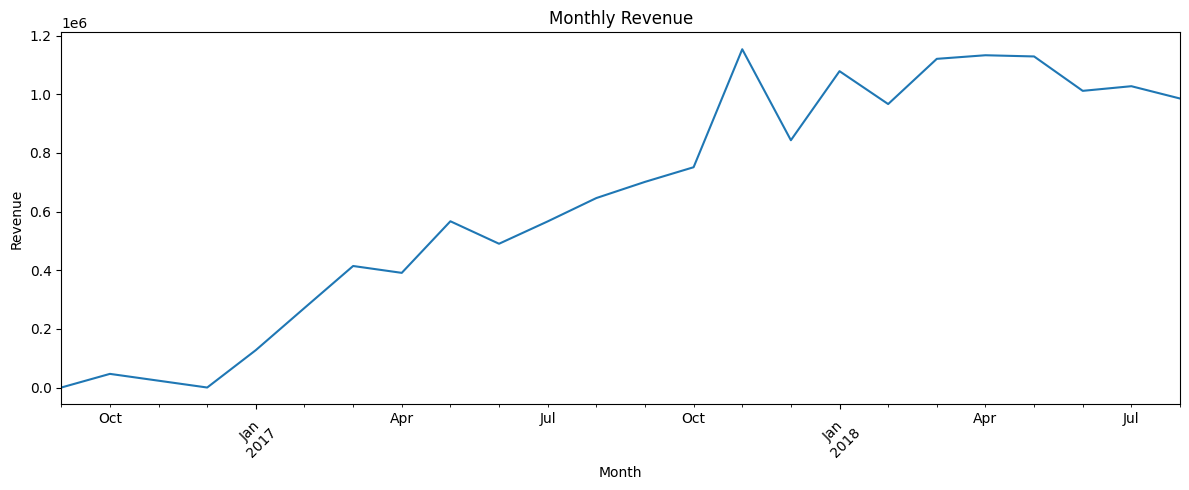

In [11]:
plt.figure(figsize=(12, 5))

revenue.plot(
    kind="line",
    title="Monthly Revenue"
)

plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8.2 Monthly Order Volume

Analyze the number of unique orders placed each month.

Comparing order volume with revenue helps determine whether revenue changes are driven by changes in the number of orders.

In [12]:
monthly_orders = (
    monthly_revenue
    .groupby("month")["order_id"]
    .nunique()
)

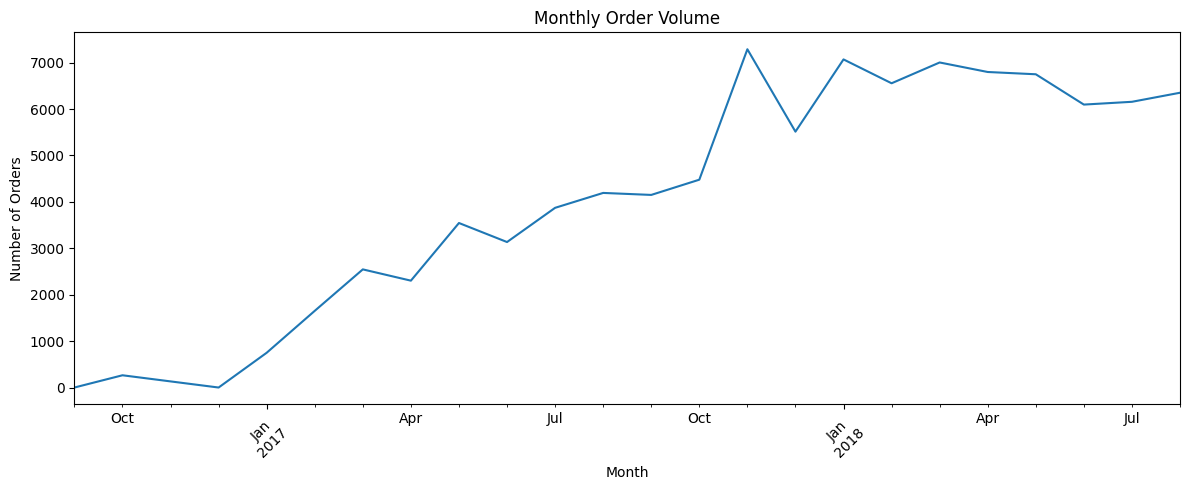

In [13]:
plt.figure(figsize=(12, 5))

monthly_orders.plot(
    kind="line",
    title="Monthly Order Volume"
)

plt.ylabel("Number of Orders")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8.3 Monthly Average Order Value

Average Order Value (AOV) measures the average amount spent per order.

A monthly AOV analysis helps determine whether changes in revenue are driven primarily by changes in order volume or by changes in the average amount spent per order.

AOV is calculated as:

**AOV = Total Revenue / Number of Unique Orders**

This provides additional context when interpreting monthly revenue and order-volume trends.


In [14]:
average_order_value = (
    payments["payment_value"].sum() / cleaned_orders["order_id"].nunique()
)
print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 159.85


In [15]:
monthly_aov = (
    monthly_revenue
    .groupby("month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_aov["aov"] = (
    monthly_aov["total_revenue"]
    / monthly_aov["total_orders"]
)

monthly_aov.round(2)

,total_revenue,total_orders,aov
month,,,
2016-09,0.00,1,0.00
2016-10,46566.71,265,175.72
2016-12,19.62,1,19.62
2017-01,127545.67,750,170.06
2017-02,271298.65,1653,164.13
2017-03,414369.39,2546,162.75
2017-04,390952.18,2303,169.76
2017-05,566872.73,3545,159.91
2017-06,490225.60,3135,156.37


## 8.4 Product Category Revenue

Analyze which product categories generate the highest revenue.

For this analysis, order-item revenue is defined as:

Order Item Value = Product Price + Freight Value

This represents the gross value associated with each order item,
including the shipping charge.

In [16]:
category_revenue = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "product_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="inner"
    )
    .merge(
        category_translation[
            [
                "product_category_name",
                "product_category_name_english"
            ]
        ],
        on="product_category_name",
        how="left"
    )
)

Create revenue:

In [17]:
category_revenue["item_revenue"] = (
    category_revenue["price"]
    + category_revenue["freight_value"]
)

Aggregate:

In [18]:
category_summary = (
    category_revenue
    .groupby("product_category_name_english")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

category_summary.head(10)

,total_orders,total_revenue
product_category_name_english,,
health_beauty,8647,1412089.53
watches_gifts,5493,1264016.98
bed_bath_table,9272,1225209.26
sports_leisure,7529,1118062.91
computers_accessories,6529,1032603.65
furniture_decor,6307,880329.92
housewares,5743,758392.25
cool_stuff,3559,691680.89
auto,3809,669319.92


### Top 10 Product Categories by Revenue

In [19]:
top_categories = (
    category_summary["total_revenue"]
    .head(10)
    .sort_values()
)

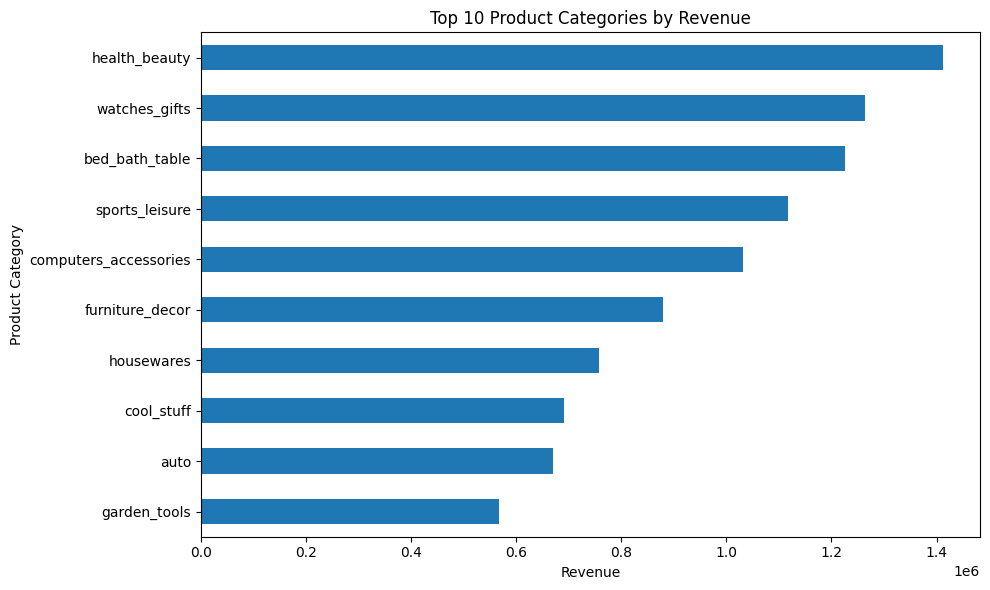

In [20]:
plt.figure(figsize=(10, 6))

top_categories.plot(
    kind="barh",
    title="Top 10 Product Categories by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

# 9. Delivery Exploratory Data Analysis

This section explores delivery performance and investigates whether delivery performance is associated with customer satisfaction.

### Key questions

1. How many orders were delivered late?
2. How long do deliveries take?
3. Which states have the highest late-delivery rates?
4. Are there unusual delivery times or outliers?
5. Is delivery performance associated with customer review scores?

## 9.1 Delivery Status Distribution

Analyze the number and percentage of orders that were delivered on time versus late.

In [21]:
delivery_summary = (
    cleaned_orders
    .groupby("delivery_status")["order_id"]
    .count()
)

delivery_percentage = (
    delivery_summary
    / delivery_summary.sum()
    * 100
)

delivery_summary

delivery_status
Late        7826
On Time    88644
Name: order_id, dtype: int64

In [22]:
delivery_percentage.round(2)

delivery_status
Late        8.11
On Time    91.89
Name: order_id, dtype: float64

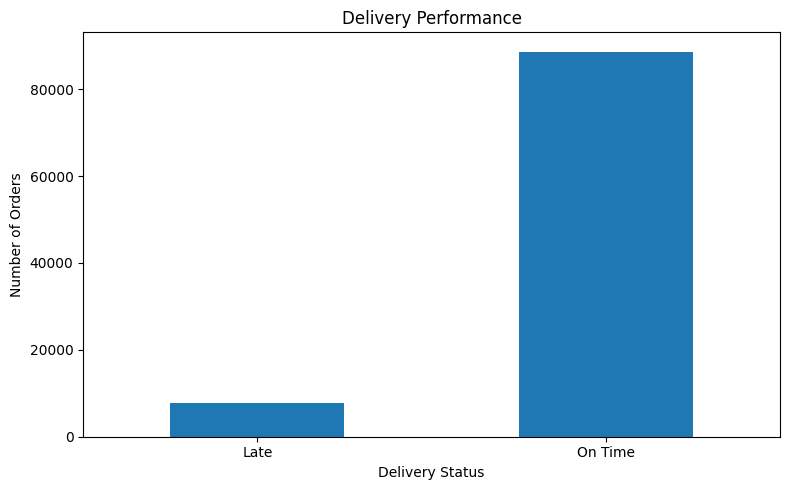

In [23]:
plt.figure(figsize=(8, 5))

delivery_summary.plot(
    kind="bar",
    title="Delivery Performance"
)

plt.ylabel("Number of Orders")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.2 Average Delivery Time

Compare actual delivery time and delivery delay between late and on-time orders.

In [24]:
delivery_time_summary = (
    cleaned_orders
    .groupby("delivery_status")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delay_days", "mean")
    )
    .round(2)
)

delivery_time_summary

,average_delivery_days,average_delay_days
delivery_status,,
Late,31.48,8.87
On Time,10.82,-13.71


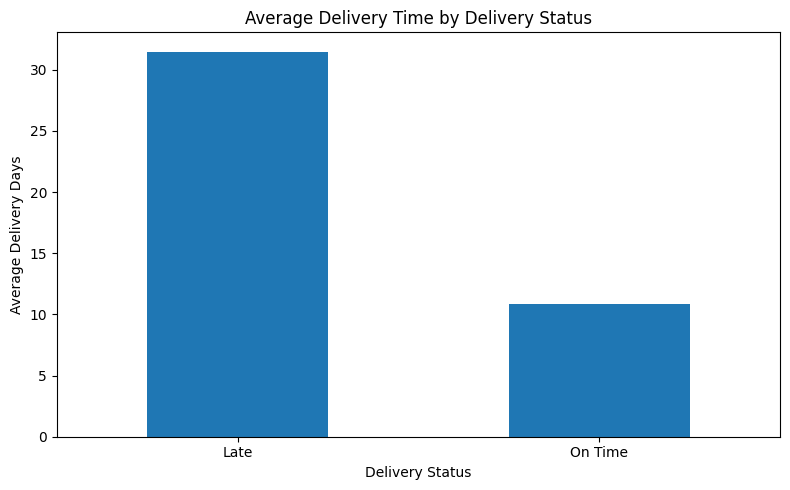

In [25]:
plt.figure(figsize=(8, 5))

delivery_time_summary[
    "average_delivery_days"
].plot(
    kind="bar",
    title="Average Delivery Time by Delivery Status"
)

plt.ylabel("Average Delivery Days")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.3 Late Delivery Rate by State

Analyze whether delivery performance varies across customer states.

The late-delivery rate is calculated as:

Late Delivery Rate = Late Orders / Total Orders × 100

In [26]:
delivery_state = (
    cleaned_orders[
        [
            "order_id",
            "customer_id",
            "delivery_status"
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

delivery_state["is_late"] = (
    delivery_state["delivery_status"] == "Late"
)

In [27]:
state_delivery = (
    delivery_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum")
    )
)

state_delivery["late_delivery_rate"] = (
    state_delivery["late_orders"]
    / state_delivery["total_orders"]
    * 100
)

state_delivery = state_delivery.sort_values(
    "late_delivery_rate",
    ascending=False
)

state_delivery.head(10)

,total_orders,late_orders,late_delivery_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


In [28]:
state_delivery_filtered = state_delivery[
    state_delivery["total_orders"] >= 100
]

top_late_states = (
    state_delivery_filtered
    .sort_values("late_delivery_rate", ascending=False)
    .head(10)
)

top_late_states

,total_orders,late_orders,late_delivery_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


### Top 10 States by Late Delivery Rate

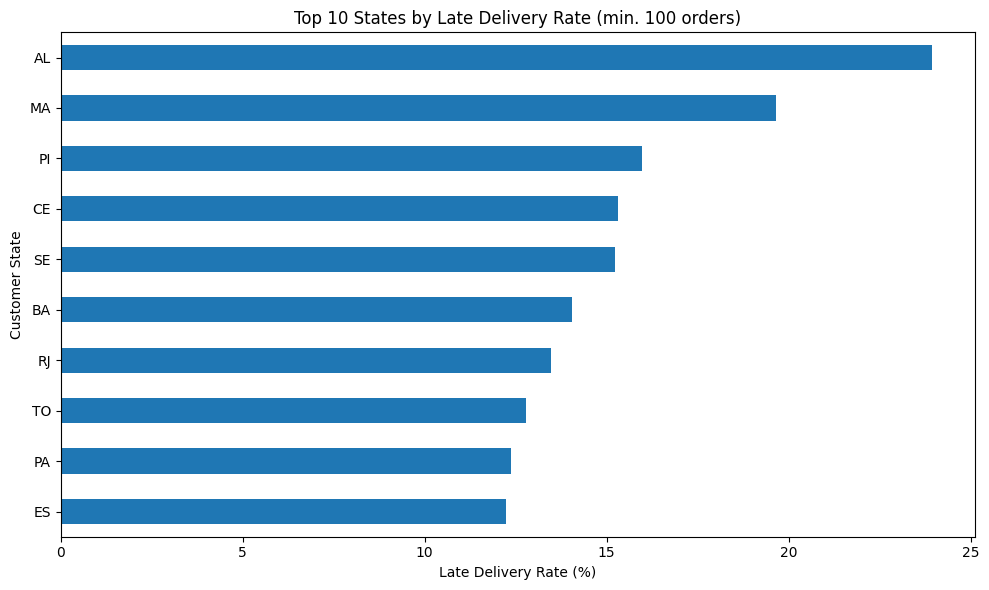

In [29]:
top_late_states_chart = (
    state_delivery_filtered["late_delivery_rate"]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_late_states_chart.plot(
    kind="barh",
    title="Top 10 States by Late Delivery Rate (min. 100 orders)"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

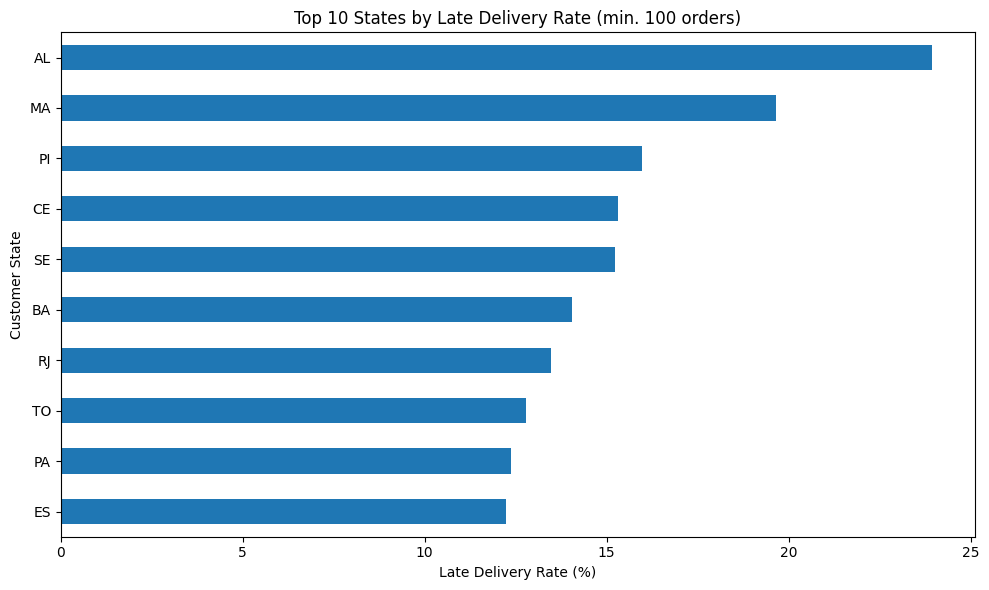

In [30]:
# Show only the late-rate series, rather than mixing counts and percentages.
ax = top_late_states["late_delivery_rate"].sort_values().plot(
    kind="barh", figsize=(10, 6),
    title="Top 10 States by Late Delivery Rate (min. 100 orders)"
)
ax.set_xlabel("Late Delivery Rate (%)")
ax.set_ylabel("Customer State")
plt.tight_layout()
plt.show()

## 9.4 Delivery Time Distribution

Examine the distribution of delivery times to identify common delivery durations and potential outliers.

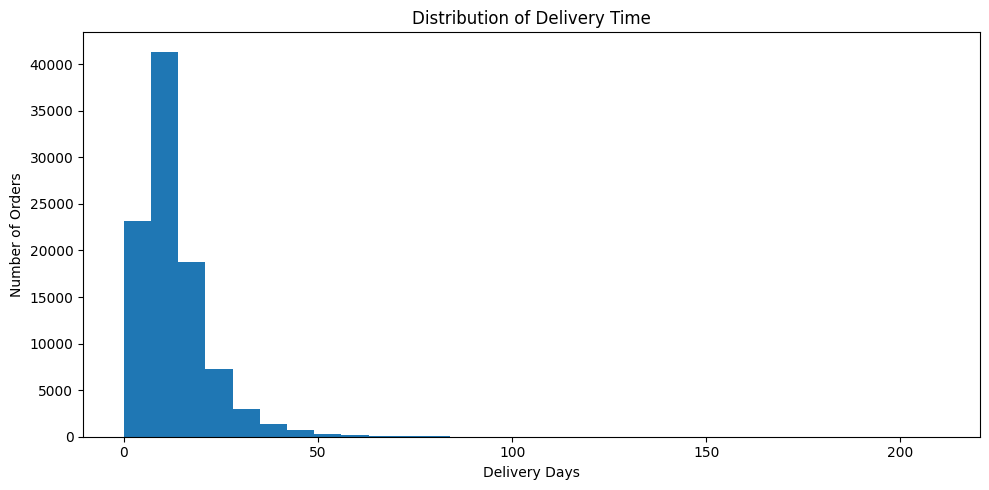

In [31]:
plt.figure(figsize=(10, 5))

cleaned_orders["delivery_days"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Delivery Time"
)

plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [32]:
cleaned_orders["delivery_days"].describe()

count    96470.000000
mean        12.496849
std          9.555071
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: delivery_days, dtype: float64

## 9.5 Delivery Performance vs Customer Satisfaction

Investigate whether late delivery is associated with lower customer review scores.

In [33]:
delivery_review = (
    cleaned_orders[
        [
            "order_id",
            "delivery_days",
            "delay_days",
            "delivery_status"
        ]
    ]
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Calculate:

In [34]:
review_by_delivery = (
    delivery_review
    .groupby("delivery_status")["review_score"]
    .mean()
    .round(2)
)

review_by_delivery

delivery_status
Late       2.57
On Time    4.29
Name: review_score, dtype: float64

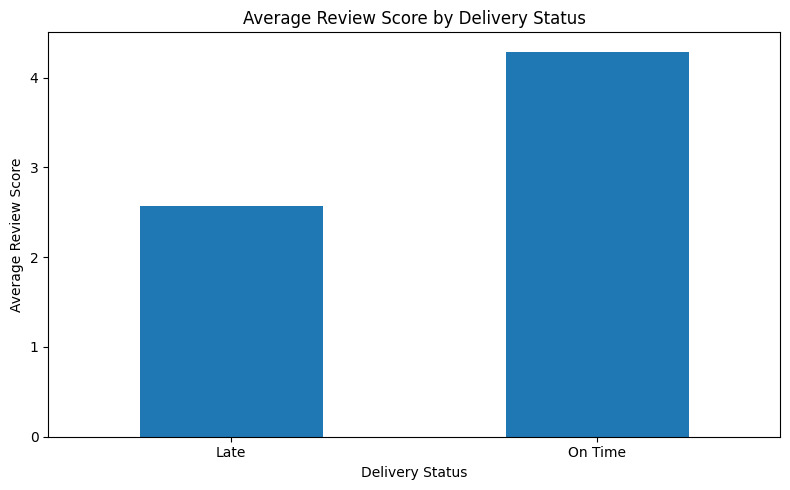

In [35]:
plt.figure(figsize=(8, 5))

review_by_delivery.plot(
    kind="bar",
    title="Average Review Score by Delivery Status"
)

plt.ylabel("Average Review Score")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.6 Delivery Time vs Review Score

Explore whether longer delivery times are associated with lower customer review scores.

A scatter plot is used to examine the relationship between delivery duration and review score.

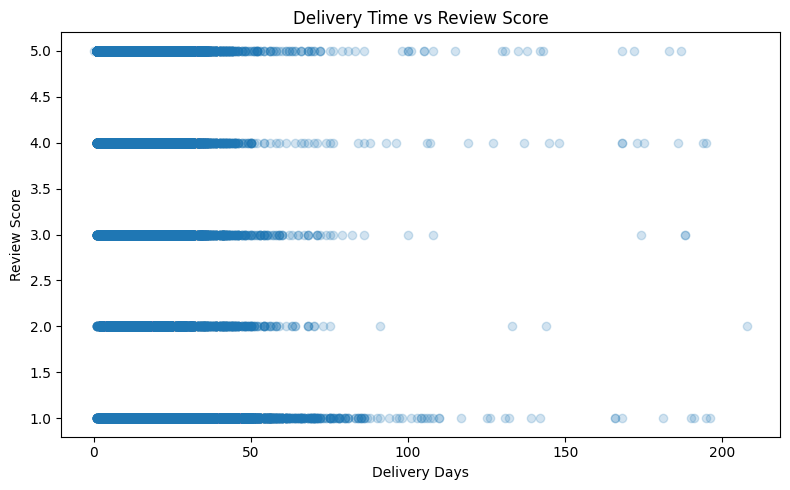

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    delivery_review["delivery_days"],
    delivery_review["review_score"],
    alpha=0.2
)

plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

Correlation:

In [37]:
delivery_review[
    [
        "delivery_days",
        "review_score"
    ]
].corr()

,delivery_days,review_score
delivery_days,1.000000,-0.333629
review_score,-0.333629,1.000000


# 10. Payment Exploratory Data Analysis

This section examines customer payment behavior, including payment method usage and payment value.

In [38]:
payment_summary = (
    payments
    .groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        total_revenue=("payment_value", "sum")
    )
    .sort_values(
        "transactions",
        ascending=False
    )
)

payment_summary

,transactions,total_revenue
payment_type,,
credit_card,74579,12100070.20
boleto,19191,2769932.58
voucher,5493,343013.19
debit_card,1485,208066.88


## 10.1 Payment Method Usage

Analyze which payment methods are most frequently used by customers.

In [39]:
payment_summary

,transactions,total_revenue
payment_type,,
credit_card,74579,12100070.20
boleto,19191,2769932.58
voucher,5493,343013.19
debit_card,1485,208066.88


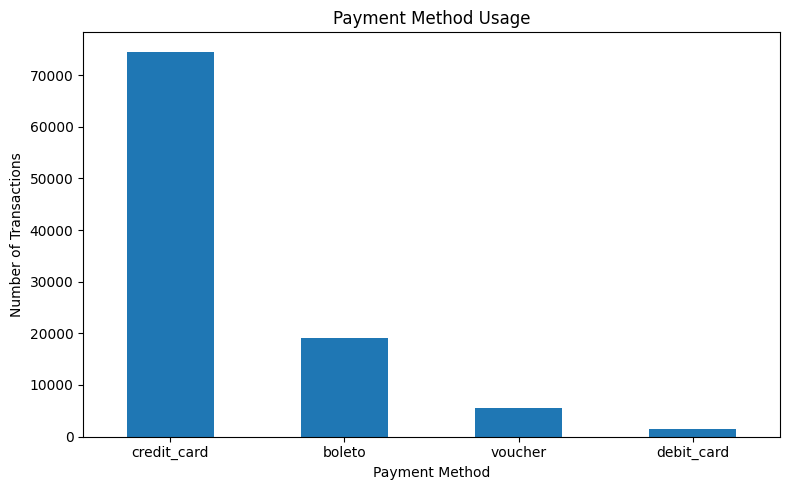

In [40]:
plt.figure(figsize=(8, 5))

payment_summary["transactions"].plot(
    kind="bar",
    title="Payment Method Usage"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10.2 Revenue by Payment Method

Compare the total revenue associated with each payment method.

In [41]:
payment_revenue = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    12100070.20
boleto          2769932.58
voucher          343013.19
debit_card       208066.88
Name: payment_value, dtype: float64

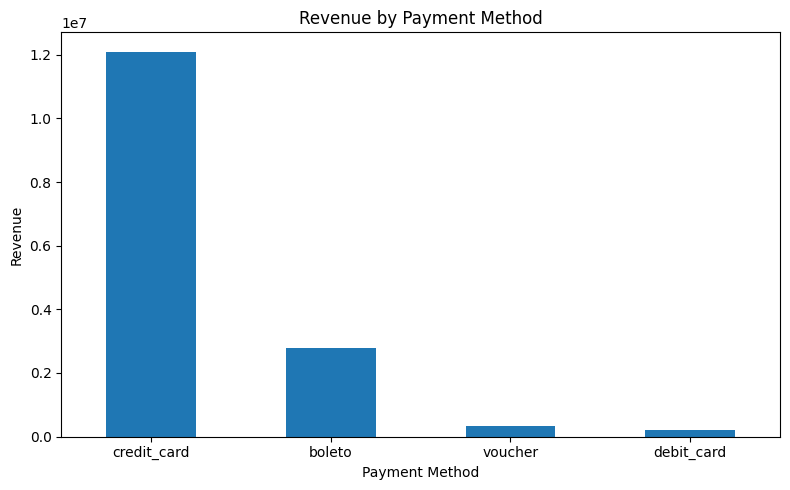

In [42]:
plt.figure(figsize=(8, 5))

payment_revenue.plot(
    kind="bar",
    title="Revenue by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10.3 Installment Payment Behavior

The chart compares payment-record averages. Zero or missing installment counts
are classified as Unspecified. The separate order-level summary classifies each
order once, matching the dashboard's installment card and donut.

In [43]:
payments["payment_group"] = np.select(
    [payments["payment_installments"] > 1,
     payments["payment_installments"] == 1],
    ["Installment", "Single Payment"],
    default="Unspecified"
)

order_payment_plan = payments.groupby("order_id")["payment_installments"].max()
order_payment_plan = order_payment_plan.gt(1).map(
    {True: "Uses installments", False: "No installments"}
)
order_payment_summary = order_payment_plan.value_counts().rename("payment_orders").to_frame()
order_payment_summary["percentage"] = (
    100 * order_payment_summary["payment_orders"] / order_payment_summary["payment_orders"].sum()
)
display(order_payment_summary.round(2))

,payment_orders,percentage
payment_installments,,
Uses installments,49656,51.47
No installments,46813,48.53


In [44]:
installment_summary = (
    payments
    .groupby("payment_group")
    .agg(
        transactions=("order_id", "count"),
        average_payment_value=("payment_value", "mean")
    )
    .round(2)
)

installment_summary

,transactions,average_payment_value
payment_group,,
Installment,49820,195.37
Single Payment,50926,111.69
Unspecified,2,94.32


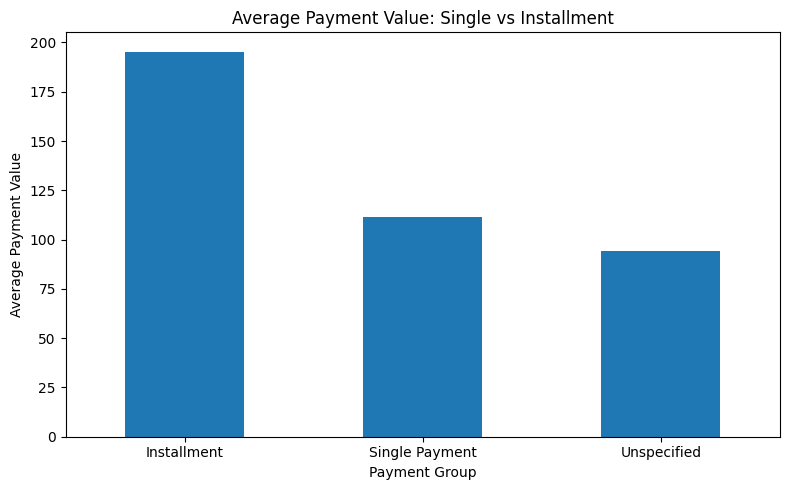

In [45]:
plt.figure(figsize=(8, 5))

installment_summary["average_payment_value"].plot(
    kind="bar",
    title="Average Payment Value: Single vs Installment"
)

plt.xlabel("Payment Group")
plt.ylabel("Average Payment Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 11. Customer Satisfaction Exploratory Data Analysis

This section explores customer satisfaction using review scores and investigates
whether delivery performance and product categories are associated with customer
satisfaction.

### Key questions

1. What is the overall average customer review score?
2. How are review scores distributed?
3. Does late delivery affect customer satisfaction?
4. Which product categories receive the most negative reviews?
5. Are there categories with high revenue but relatively low satisfaction?

## 11.1 Overall Customer Satisfaction

Calculate the mean of review records belonging to eligible delivered orders.
An order may have more than one review record; no item-row weighting is used.

In [46]:
average_review_score = reviews["review_score"].mean()

print(f"Average Customer Review Score: {average_review_score:.2f}")

Average Customer Review Score: 4.16


In [47]:
review_summary = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_summary

review_score
1     9405
2     2941
3     7961
4    18987
5    57059
Name: count, dtype: int64

## 11.2 Review Score Distribution

Examine the distribution of delivered-order review records across scores 1 to 5.

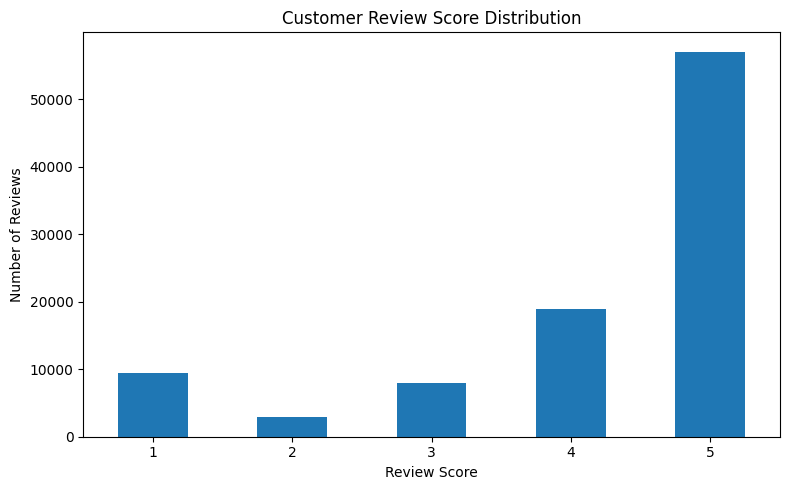

In [48]:
plt.figure(figsize=(8, 5))

review_summary.plot(
    kind="bar",
    title="Customer Review Score Distribution"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 11.3 Negative Reviews by Product Category

Negative = score 1 or 2. The denominator is review records, matching Power BI.
Each review appears once per category in its order, regardless of item quantity.
The full table includes small categories; the EDA ranking requires 20 reviews.
That sample threshold can make this ranking differ from an unfiltered PBI Top 5.

In [49]:
order_category = (
    order_items[["order_id", "product_id"]]
    .merge(products[["product_id", "product_category_name"]],
           on="product_id", how="left", validate="many_to_one")
    .merge(category_translation[["product_category_name", "product_category_name_english"]],
           on="product_category_name", how="left", validate="many_to_one")
    [["order_id", "product_category_name_english"]]
    .drop_duplicates()
)
# Keep review records intact. Deduplicate only the order/category mapping.
negative_reviews = order_category.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="inner"
)

Create the negative-review flag:

In [50]:
negative_reviews["is_negative"] = negative_reviews["review_score"].isin([1, 2])

Aggregate:

In [51]:
category_review_summary = (
    negative_reviews.groupby("product_category_name_english", dropna=False)
    .agg(reviewed_orders=("order_id", "nunique"),
         total_reviews=("review_score", "count"),
         negative_reviews=("is_negative", "sum"))
)
category_review_summary["negative_review_rate"] = (
    100 * category_review_summary["negative_reviews"] / category_review_summary["total_reviews"]
)
# Omit unknown categories from the ranked chart, but retain them in the table.
category_review_summary_filtered = category_review_summary[
    (category_review_summary["total_reviews"] >= 20)
    & category_review_summary.index.notna()
].sort_values("negative_review_rate", ascending=False)
category_review_summary_filtered.head(10)

,reviewed_orders,total_reviews,negative_reviews,negative_review_rate
product_category_name_english,,,,
fashion_male_clothing,105,105,24,22.857143
office_furniture,1244,1249,275,22.017614
audio,345,346,76,21.965318
home_comfort_2,23,23,5,21.739130
furniture_mattress_and_upholstery,37,37,7,18.918919
home_confort,390,393,74,18.829517
home_construction,481,482,83,17.219917
construction_tools_safety,158,158,27,17.088608
fixed_telephony,209,210,35,16.666667


## 11.4 Visualize Negative Review Rates

Top 10 named categories with at least 20 review records.

In [52]:
top_negative_categories = (
    category_review_summary_filtered[
        "negative_review_rate"
    ]
    .head(10)
    .sort_values()
)

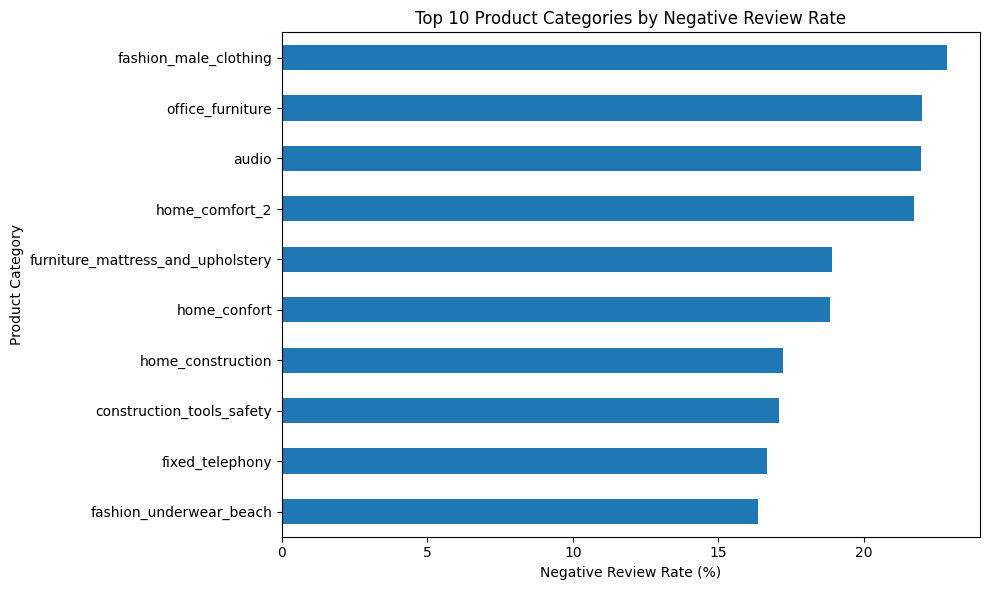

In [53]:
plt.figure(figsize=(10, 6))

top_negative_categories.plot(
    kind="barh",
    title="Top 10 Product Categories by Negative Review Rate"
)

plt.xlabel("Negative Review Rate (%)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## 11.5 High Revenue but Low Customer Satisfaction

Identify product categories that generate substantial revenue but receive
relatively low customer review scores.

This helps identify categories that may generate strong sales while presenting
potential customer experience issues.

In [54]:
category_reviews = order_category.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="inner"
)

In [55]:
category_satisfaction = (
    category_reviews.groupby("product_category_name_english", dropna=False)
    .agg(average_review_score=("review_score", "mean"),
         total_reviews=("review_score", "count"),
         reviewed_orders=("order_id", "nunique"))
)
category_satisfaction.round(2)

,average_review_score,total_reviews,reviewed_orders
product_category_name_english,,,
agro_industry_and_commerce,4.11,177,177
air_conditioning,4.12,242,242
art,4.10,193,193
arts_and_craftmanship,4.17,23,23
audio,3.83,346,345
...,...,...,...
tablets_printing_image,4.16,77,77
telephony,4.05,4073,4069
toys,4.24,3781,3773


In [57]:
category_performance = category_summary.merge(
    category_satisfaction,
    left_index=True,
    right_index=True,
    how="inner"
)

category_performance = category_performance.sort_values(
    "total_revenue",
    ascending=False
)

category_performance.head(10)

,total_orders,total_revenue,average_review_score,total_reviews,reviewed_orders
product_category_name_english,,,,,
health_beauty,8647,1412089.53,4.230414,8654,8601
watches_gifts,5493,1264016.98,4.121018,5462,5452
bed_bath_table,9272,1225209.26,3.996880,9295,9177
sports_leisure,7529,1118062.91,4.228503,7536,7485
computers_accessories,6529,1032603.65,4.081552,6548,6498
furniture_decor,6307,880329.92,4.054773,6317,6260
housewares,5743,758392.25,4.194939,5730,5709
cool_stuff,3559,691680.89,4.216667,3540,3531
auto,3809,669319.92,4.146047,3807,3791


In [58]:
top_revenue_categories = category_performance[
    category_performance["total_revenue"] >=
    category_performance["total_revenue"].quantile(0.75)
]

satisfaction_threshold = top_revenue_categories["average_review_score"].quantile(0.25)

high_revenue_low_satisfaction = (
    top_revenue_categories[
        top_revenue_categories["average_review_score"] <= satisfaction_threshold
    ]
    .sort_values("average_review_score")
)

high_revenue_low_satisfaction

,total_orders,total_revenue,average_review_score,total_reviews,reviewed_orders
product_category_name_english,,,,,
office_furniture,1254,335211.36,3.643715,1249,1244
bed_bath_table,9272,1225209.26,3.996880,9295,9177
telephony,4093,379202.62,4.052541,4073,4069
furniture_decor,6307,880329.92,4.054773,6317,6260
computers_accessories,6529,1032603.65,4.081552,6548,6498


# 12. Seller Performance Exploratory Data Analysis

This section evaluates seller performance based on revenue generation,
order volume, and customer satisfaction.

### Key questions

1. Which sellers generate the highest revenue?
2. Which sellers handle the highest number of orders?
3. Which sellers generate high revenue but have relatively low customer satisfaction?
4. Are there sellers that may require further investigation?

## 12.1 Top Sellers by Revenue

Identify the sellers generating the highest revenue from delivered orders.

Seller revenue is calculated using product price and freight value.

In [59]:
seller_revenue = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "seller_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Calculate seller revenue:

In [60]:
seller_revenue["seller_revenue"] = (
    seller_revenue["price"]
    + seller_revenue["freight_value"]
)

Aggregate:

In [61]:
seller_summary = (
    seller_revenue
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("seller_revenue", "sum")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

seller_summary.head(10)

,total_orders,total_revenue
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,1124,247007.06
7c67e1448b00f6e969d365cea6b010ab,973,237806.69
4a3ca9315b744ce9f8e9374361493884,1772,231220.43
53243585a1d6dc2643021fd1853d8905,348,230797.02
fa1c13f2614d7b5c4749cbc52fecda94,578,200833.50
da8622b14eb17ae2831f4ac5b9dab84a,1311,184706.78
7e93a43ef30c4f03f38b393420bc753a,319,171973.55
1025f0e2d44d7041d6cf58b6550e0bfa,910,171924.96
7a67c85e85bb2ce8582c35f2203ad736,1145,160278.52


## 12.2 Top 10 Sellers Visualization
### Top 10 Sellers by Revenue

In [62]:
top_sellers = (
    seller_summary[
        "total_revenue"
    ]
    .head(10)
    .sort_values()
)

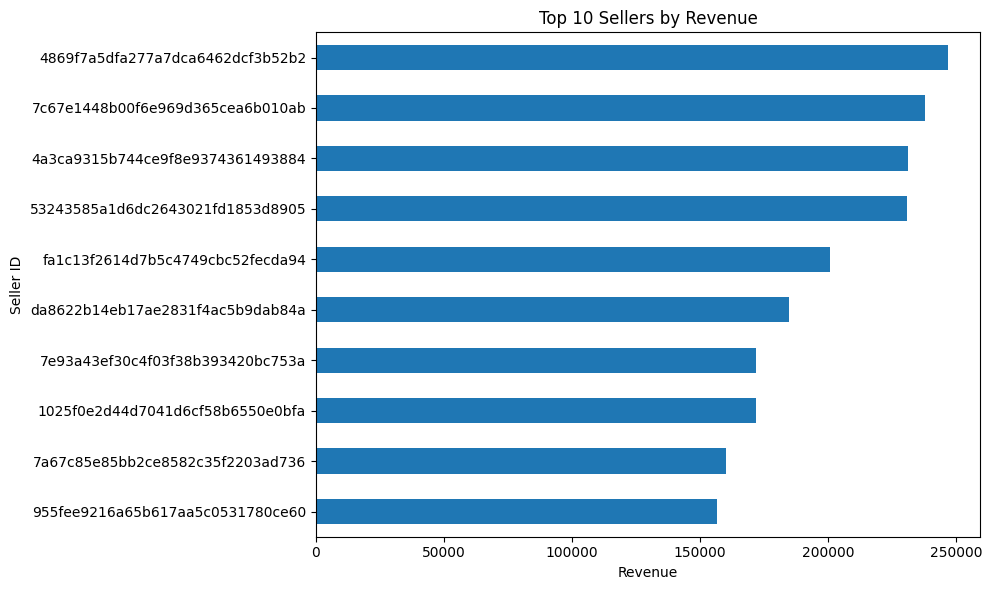

In [63]:
plt.figure(figsize=(10, 6))

top_sellers.plot(
    kind="barh",
    title="Top 10 Sellers by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

## 12.3 Top Sellers by Order Volume

Analyze which sellers handle the highest number of orders.

Comparing order volume with revenue helps identify whether seller performance
is driven by order quantity or higher-value products.

In [64]:
top_sellers_orders = (
    seller_summary[
        "total_orders"
    ]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

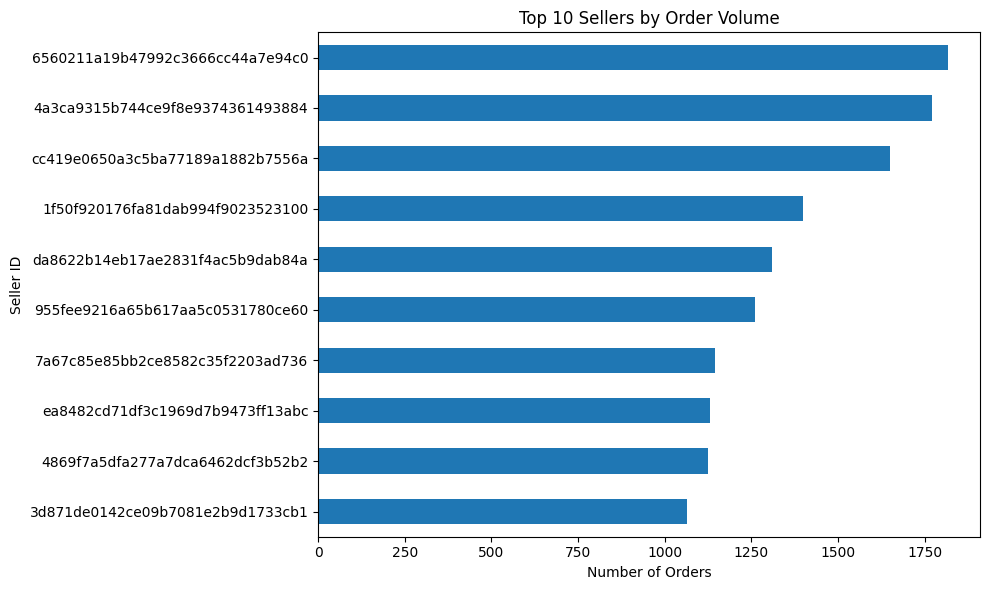

In [65]:
plt.figure(figsize=(10, 6))

top_sellers_orders.plot(
    kind="barh",
    title="Top 10 Sellers by Order Volume"
)

plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

## 12.4 Seller Customer Satisfaction

Associate order-level reviews with each seller in that order. A review is counted
once per seller, even if the seller supplied multiple items. Multi-seller order
reviews cannot establish which individual seller caused the customer's rating.

In [66]:
order_seller = order_items[["order_id", "seller_id"]].drop_duplicates()
seller_reviews = order_seller.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="inner"
)

Aggregate:

In [67]:
seller_satisfaction = (
    seller_reviews.groupby("seller_id")
    .agg(total_reviews=("review_score", "count"),
         reviewed_orders=("order_id", "nunique"),
         average_review_score=("review_score", "mean"))
)
seller_satisfaction.round(2)

,total_reviews,reviewed_orders,average_review_score
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,3,3.67
001cca7ae9ae17fb1caed9dfb1094831,192,192,4.06
002100f778ceb8431b7a1020ff7ab48f,51,50,3.96
003554e2dce176b5555353e4f3555ac8,1,1,5.00
004c9cd9d87a3c30c522c48c4fc07416,160,154,4.15
...,...,...,...
ffc470761de7d0232558ba5e786e57b7,27,27,4.44
ffdd9f82b9a447f6f8d4b91554cc7dd3,18,18,4.33
ffeee66ac5d5a62fe688b9d26f83f534,14,14,4.21


## 12.5 High Revenue but Low Customer Satisfaction

Rank sellers with at least 20 delivered orders and a review-record mean below 3.5,
matching the eligibility rule in `07_seller_analysis.sql`.

In [68]:
seller_performance = seller_summary.merge(
    seller_satisfaction, left_index=True, right_index=True, how="left",
    validate="one_to_one"
)

Filter:

In [69]:
high_revenue_low_satisfaction = seller_performance[
    (seller_performance["total_orders"] >= 20)
    & (seller_performance["average_review_score"] < 3.5)
].sort_values("total_revenue", ascending=False)
high_revenue_low_satisfaction.head(10)

,total_orders,total_revenue,total_reviews,reviewed_orders,average_review_score
seller_id,,,,,
7c67e1448b00f6e969d365cea6b010ab,973,237806.69,973.0,967.0,3.498458
712e6ed8aa4aa1fa65dab41fed5737e4,77,46149.82,77.0,76.0,3.402597
2eb70248d66e0e3ef83659f71b244378,187,42046.73,185.0,184.0,2.789189
88460e8ebdecbfecb5f9601833981930,246,36258.59,251.0,245.0,3.450199
710e3548e02bc1d2831dfc4f1b5b14d4,131,26111.91,130.0,130.0,3.430769
8444e55c1f13cd5c179851e5ca5ebd00,92,23445.67,92.0,92.0,3.369565
821fb029fc6e495ca4f08a35d51e53a5,24,19217.17,23.0,23.0,3.478261
a7f13822ceb966b076af67121f87b063,73,14980.43,72.0,72.0,3.402778
0b35c634521043bf4b47e21547b99ab5,50,14690.79,49.0,49.0,3.408163


## 12.6 Seller Revenue vs Customer Satisfaction

Show sellers with at least 20 delivered orders. Ratings are order-level reviews
associated with sellers, not independent seller-specific ratings.

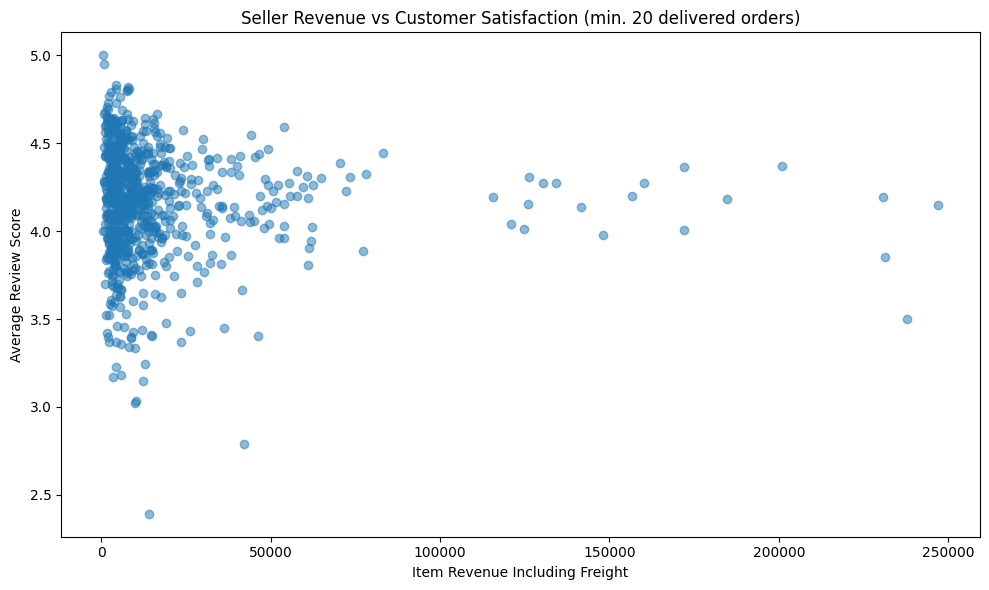

In [70]:
seller_plot = seller_performance[seller_performance["total_orders"] >= 20]
plt.figure(figsize=(10, 6))
plt.scatter(seller_plot["total_revenue"], seller_plot["average_review_score"], alpha=0.5)
plt.xlabel("Item Revenue Including Freight")
plt.ylabel("Average Review Score")
plt.title("Seller Revenue vs Customer Satisfaction (min. 20 delivered orders)")
plt.tight_layout()
plt.show()

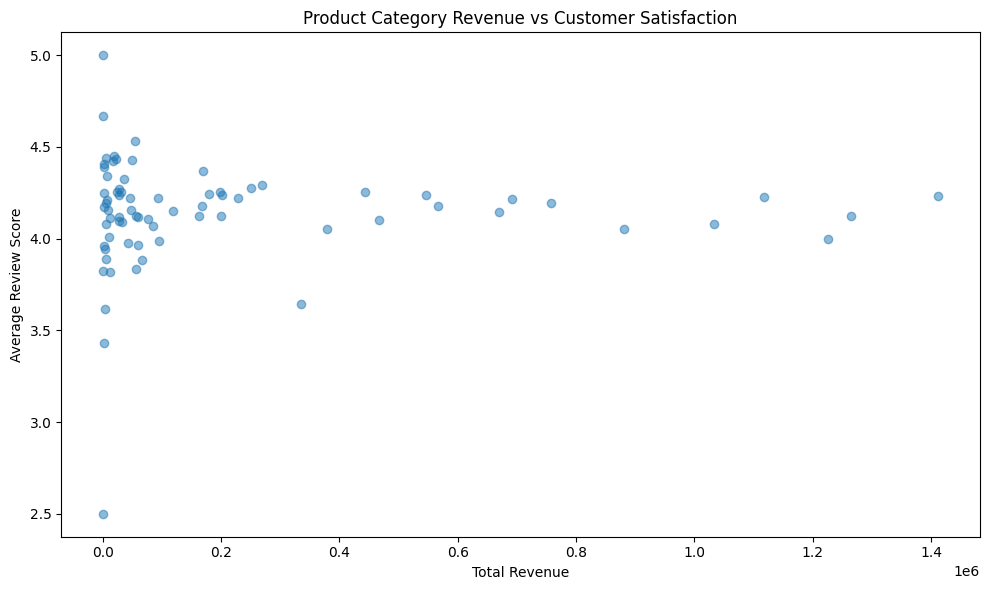

In [71]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_performance["total_revenue"],
    category_performance["average_review_score"],
    alpha=0.5
)

plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")
plt.title("Product Category Revenue vs Customer Satisfaction")

plt.tight_layout()
plt.show()

# 13. EDA Summary and Interpretation

- All business analyses use delivered orders with an actual delivery date.
- AOV uses all eligible delivered orders; payment-method averages use payment records.
- Reviews are counted once per order/category or order/seller association, not once per item.
- Negative-review rates use review records, not the number of orders with a negative review.
- The category negative-review chart requires 20 reviews; the full table has no minimum.
- Seller comparisons use at least 20 delivered orders where stated.
- Blank categories are retained in the full review summary but excluded from named-category charts.
- Dataset boundaries contain partial periods. Compare complete periods when discussing growth.
- Delivery/review relationships describe associations, not proof of causation.

Run the notebook before drawing new conclusions or exporting charts. The README
contains the previously reconciled dashboard totals; this notebook's outputs must
be regenerated from the local MySQL database.